In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


In [5]:
train_dataset = datasets.ImageFolder(
    root='cifar10_sampled/train',
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root='cifar10_sampled/val',
    transform=train_transform
)


In [6]:
train_loader = DataLoader(train_dataset, batch_size=3, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=3, shuffle=False)


torch.Size([3, 3, 128, 128])


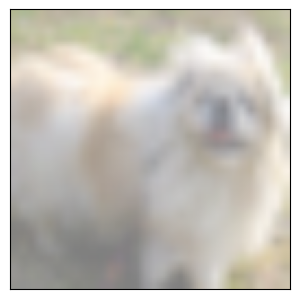

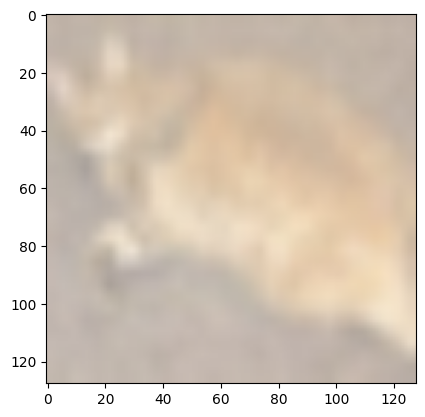

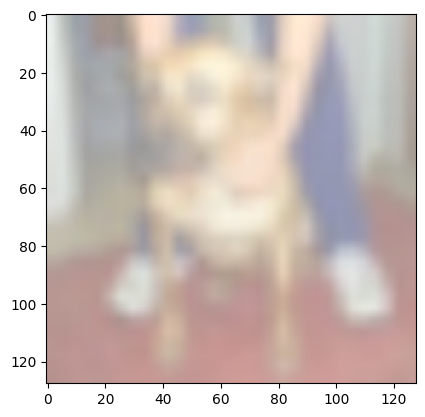

In [7]:
# Function to show images
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))  # convert from Tensor image
    plt.imshow(img)
    plt.show()

# Get a batch of training data
images, labels = next(iter(train_loader))
print(images.shape)
# Show images
fig = plt.figure(figsize=(8, 8))
for idx in range(3):
    ax = fig.add_subplot(2, 2, idx + 1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(train_dataset.classes[labels[idx]])

In [8]:
num_classes = len(train_dataset.classes)
print(train_dataset.classes)  


['cat', 'dog']


In [9]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        
        self.fc1 = nn.Linear(32 * (128//4) * (128//4), 64) 
        self.fc2 = nn.Linear(64, num_classes)
    
    
    
    
    
    def forward(self, x):
        # print(x.shape)
        x = F.relu(self.conv1(x))
        # print(x.shape)
        x = self.pool(x)
        # print(x.shape)
        x = F.relu(self.conv2(x))
        # print(x.shape)
        x = self.pool(x)
        # print(x.shape)
        x = x.view(x.size(0), -1)
        # print(x.shape)
        x = F.relu(self.fc1(x))
        # print(x.shape)
        x = self.fc2(x)
        # print(x.shape)
        return x


In [10]:
import torch.optim as optim

model = SimpleCNN(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}')


Epoch [1/20], Loss: 0.8565
Epoch [2/20], Loss: 0.6964
Epoch [3/20], Loss: 0.6978
Epoch [4/20], Loss: 0.6982
Epoch [5/20], Loss: 0.6972
Epoch [6/20], Loss: 0.6953
Epoch [7/20], Loss: 0.6922
Epoch [8/20], Loss: 0.7035
Epoch [9/20], Loss: 0.6916
Epoch [10/20], Loss: 0.6878
Epoch [11/20], Loss: 0.6944
Epoch [12/20], Loss: 0.6917
Epoch [13/20], Loss: 0.6882
Epoch [14/20], Loss: 0.6858
Epoch [15/20], Loss: 0.6845
Epoch [16/20], Loss: 0.6820
Epoch [17/20], Loss: 0.6719
Epoch [18/20], Loss: 0.6813
Epoch [19/20], Loss: 0.7037
Epoch [20/20], Loss: 0.7110


In [11]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Validation Accuracy: {accuracy:.2f}%')


Validation Accuracy: 50.00%


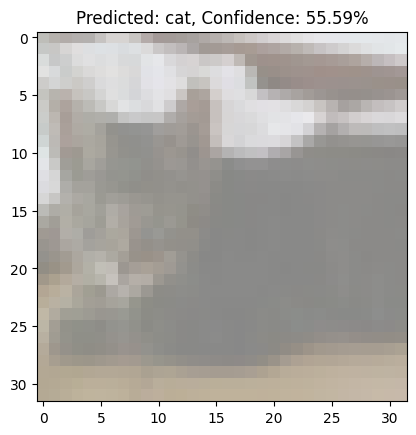

In [13]:
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Load and transform the external image
image_path = r'cifar10_sampled\train\cat\cat_9.png'
image = Image.open(image_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])
image = transform(image).unsqueeze(0)  # Add batch dimension

# Assume 'model' is your trained SimpleCNN model
model.eval()  # Set the model to evaluation mode

# Predict
with torch.no_grad():
    outputs = model(image)
    probabilities = F.softmax(outputs, dim=1)  # Apply softmax to convert to probabilities
    max_prob, predicted = torch.max(probabilities, 1)  # Get the prediction and its confidence

# Load the image for displaying
image_display = Image.open(image_path)
plt.imshow(image_display)
predicted_class = val_dataset.classes[predicted[0]]
plt.title(f'Predicted: {predicted_class}, Confidence: {max_prob.item()*100:.2f}%')
plt.show()


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define a Conv2d layer
conv_layer = nn.Conv2d(in_channels=1, out_channels=100, kernel_size=3, stride=1, padding=1)





# Define a MaxPool2d layer
pool_layer = nn.MaxPool2d(kernel_size=2, stride=2)


# Creating a random single-channel image tensor of size (1, 1, 8, 8)
# Format: (batch_size, channels, height, width)
input_image = torch.rand(1, 1, 8, 8)
print("Input Shape:", input_image.shape)


Input Shape: torch.Size([1, 1, 8, 8])


In [15]:
# Applying the convolutional layer
output_from_conv = conv_layer(input_image)
print("Output Shape from Conv2d:", output_from_conv.shape)


Output Shape from Conv2d: torch.Size([1, 100, 8, 8])


In [16]:
# Applying the max pooling layer
output_from_pool = pool_layer(output_from_conv)
print("Output Shape from MaxPool2d:", output_from_pool.shape)


Output Shape from MaxPool2d: torch.Size([1, 100, 4, 4])
